In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle as pkl
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import plot_formatting as pf


# 1 Load and View Results Pickle

In [4]:
results_data = "outputs/09012026_scenario_analysis_results.pkl"
with open(results_data, 'rb') as f:
    results = pkl.load(f)

In [55]:
beam = "direct"
baseline_feather = f"raytracing_results/baseline_{beam}.feather"
baseline_df = pd.read_feather(baseline_feather)



In [58]:
scenario_feather = results['scenario_metadata']['scenario_000'][f'{beam}_path']
scenario_df = pd.read_feather(scenario_feather)
comp = baseline_df - scenario_df

In [59]:
n_days = 9*24
analysis_period = (4344+n_days+6,4344+n_days+6+18)
comp.transpose().loc[analysis_period[0]:analysis_period[1]]

,0,1,2,3,4,5,6,7,8,9,...,42187,42188,42189,42190,42191,42192,42193,42194,42195,42196
4566,0.29,7.58,0.10,0.43,7.77,0.0,7.56,0.38,9.08,0.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4567,0.22,7.65,0.10,0.17,0.38,0.0,7.56,0.41,9.11,0.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4568,0.57,7.70,0.10,0.43,0.31,0.0,7.56,0.36,9.43,1.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4569,0.57,0.10,0.10,0.53,7.56,0.0,0.00,0.22,9.35,1.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4570,0.44,0.01,0.10,0.21,7.66,0.0,0.00,0.35,9.53,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4571,0.75,0.31,0.43,0.50,0.41,0.0,0.00,0.78,9.61,0.44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4572,0.64,0.10,0.46,0.51,0.55,0.0,0.00,0.48,10.00,0.91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4573,0.83,0.09,0.25,0.19,0.81,0.0,0.00,0.42,10.37,0.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4574,0.72,0.10,0.38,0.30,7.65,0.0,0.00,0.54,10.59,2.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4575,0.74,0.10,0.28,0.62,7.65,0.0,0.00,0.29,11.03,2.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df24

,Unnamed: 0,tree_id,hour,T_leaf,Tsurf,MRT,ET,LE,H,gc,rs,theta,VPD,Kabs,Rn
0,0,0,4224,16.191924,11.835032,10.366417,4.309685e-08,0.029330,-30.191689,0.0,1000000.0,0.300000,0.165748,0.0,-30.119322
1,1,1,4224,16.192566,11.835032,10.844053,4.310090e-08,0.029333,-27.790957,0.0,1000000.0,0.300000,0.165748,0.0,-27.722010
2,2,2,4224,16.192228,11.835032,10.592509,4.309876e-08,0.029331,-29.056798,0.0,1000000.0,0.300000,0.165748,0.0,-28.986047
3,3,3,4224,16.192111,11.835032,10.505615,4.309803e-08,0.029331,-29.493294,0.0,1000000.0,0.300000,0.165748,0.0,-29.421922
4,4,4,4224,16.192742,11.835032,10.973900,4.310200e-08,0.029333,-27.136212,0.0,1000000.0,0.300000,0.165748,0.0,-27.068197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24691,24691,142,4391,16.997638,14.737521,14.263599,4.371984e-08,0.029754,-14.527943,0.0,1000000.0,0.286551,0.116264,0.0,-14.485497
24692,24692,143,4391,16.997627,14.737521,14.250522,4.371976e-08,0.029754,-14.596242,0.0,1000000.0,0.151750,0.116264,0.0,-14.553736
24693,24693,144,4391,16.997549,14.737521,14.158933,4.371925e-08,0.029753,-15.074333,0.0,1000000.0,0.269484,0.116264,0.0,-15.031409
24694,24694,145,4391,16.997571,14.737521,14.185110,4.371939e-08,0.029753,-14.937736,0.0,1000000.0,0.299986,0.116264,0.0,-14.894931


In [14]:

import pandas as pd

df0 = pd.read_csv("/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/debug_outputs/biophysical_results_scenario_000.csv")
df12 = pd.read_csv("/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/debug_outputs/biophysical_results_scenario_012.csv")
df24 = pd.read_csv("/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/debug_outputs/biophysical_results_scenario_024.csv")

# sam = df0[df0['hour'] == 4344+10].sample(10)
# idx = sam.index

# df24[df24['hour'] == 4344+10].loc[idx] - sam


,Unnamed: 0,tree_id,hour,T_leaf,Tsurf,MRT,ET,LE,H,gc,rs,theta,VPD,Kabs,Rn
640173,640173,135,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.298157,0.770972,0.0,-70.525475
640080,640080,42,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.297814,0.770972,0.0,-70.525475
640136,640136,98,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.299041,0.770972,0.0,-70.525475
640109,640109,71,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.298825,0.770972,0.0,-70.525475
640067,640067,29,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.295805,0.770972,0.0,-70.525475
640164,640164,126,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.298294,0.770972,0.0,-70.525475
640133,640133,95,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.299579,0.770972,0.0,-70.525475
640182,640182,144,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.298922,0.770972,0.0,-70.525475
640130,640130,92,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.298544,0.770972,0.0,-70.525475
640121,640121,83,4354,20.989725,14.953942,7.639466,6.842194e-08,0.046565,-70.630159,0.0,1000000.0,0.298035,0.770972,0.0,-70.525475


# Plots

## Scenario Concept

In [5]:
import run_analysis

pct_df = pd.read_csv('analysis_outputs/pct_change_summary.csv')
sensitivity_df = run_analysis.run_sensitivity_analysis(pct_df)
sensitivity_df.head()





SECTION 4: SENSITIVITY ANALYSIS

   Calculating area-weighted material properties...

   Risk vs Albedo:
      Slope: 61.04 %/unit albedo
      R²: 0.871
      p-value: 0.0000

   Risk vs Emissivity:
      Slope: -194.21 %/unit emissivity
      R²: 0.638
      p-value: 0.0000

   Tsurf vs Albedo:
      Slope: -89.39 %/unit albedo
      R²: 0.898
      p-value: 0.0000

   Risk vs Landscape Albedo:
      Slope: 55.06 %/unit albedo
      R²: 0.076
      p-value: 0.1832

   Risk vs Landscape Emissivity:
      Slope: 192.72 %/unit emissivity
      R²: 0.076
      p-value: 0.1832

   Risk vs Facade Albedo:
      Slope: 24.98 %/unit albedo
      R²: 0.782
      p-value: 0.0000

   Risk vs Facade Emissivity:
      Slope: -96.09 %/unit emissivity
      R²: 0.782
      p-value: 0.0000

   Saved: /Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/analysis_outputs/sensitivity_analysis.csv


,scenario_id,landscape_ratio,facade_ratio,mean_albedo,mean_emissivity,total_area,landscape_albedo,landscape_emissivity,landscape_area,facade_albedo,facade_emissivity,facade_area,degree_hours_pct_change,mean_Tsurf_C_pct_change,mean_MRT_C_pct_change
0,scenario_000,0.00,0.0,0.358600,0.902590,74466.84,0.1,0.95,42371.61,0.700000,0.840000,32095.23,8.330933,-10.021975,-9.605575
1,scenario_001,0.25,0.0,0.306619,0.916105,74466.84,0.1,0.95,42371.61,0.579394,0.871358,32095.23,3.095496,-7.388818,-7.094884
2,scenario_002,0.50,0.0,0.279189,0.923237,74466.84,0.1,0.95,42371.61,0.515752,0.887904,32095.23,-1.881263,3.950110,3.780760
3,scenario_003,0.75,0.0,0.193554,0.945502,74466.84,0.1,0.95,42371.61,0.317062,0.939564,32095.23,-4.560225,3.163860,3.131214
4,scenario_004,1.00,0.0,0.143100,0.958620,74466.84,0.1,0.95,42371.61,0.200000,0.970000,32095.23,-5.208572,9.662670,9.297007


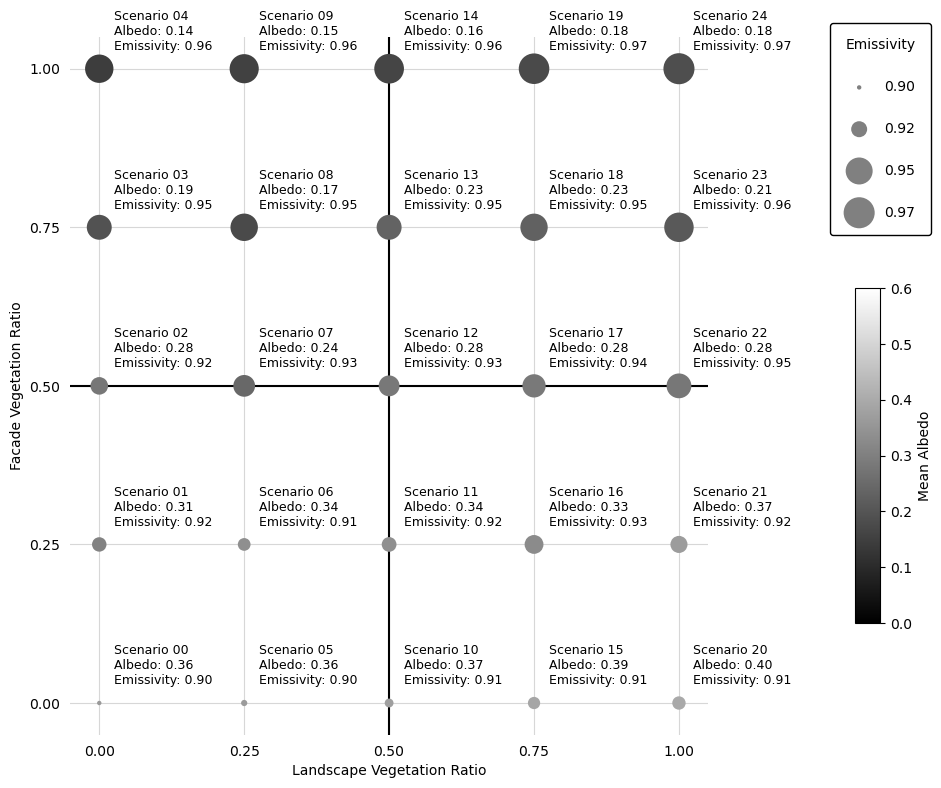

In [8]:
"""
Create a simple x,y scatter using plot_df with a point at each row. 
Modify the axes so the vertical axis appears at x=0.5 and the horitzontal at y=0.5 like a quadrant plot. 
The x axis is landscape materials and the y is facade materials. 
The 0 to 1 on both axes is "least natural to most natural"
"""
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# Create the 25 scenarios
predefined_scenarios = []
for x in np.arange(0,1.1,0.25):
    for y in np.arange(0,1.1,0.25):
        predefined_scenarios.append((x,y))
        
plot_df = pd.DataFrame(predefined_scenarios) 

fig, ax = plt.subplots(figsize=(10,8))

# draw axes
ax.vlines(0.5, -0.1, 1.1, color='black', zorder=10)
ax.hlines(0.5, -0.1, 1.1, color='black', zorder=10)

# Map albedo to color and emissivity to size
albedo_values = sensitivity_df['mean_albedo'].values
emissivity_values = sensitivity_df['mean_emissivity'].values

# Normalize emissivity to reasonable point sizes (e.g., 50 to 300)
size_min, size_max = 10, 500
emissivity_min, emissivity_max = emissivity_values.min(), emissivity_values.max()
sizes = size_min + (emissivity_values - emissivity_min) / (emissivity_max - emissivity_min) * (size_max - size_min)

# Create the scatter plot with color mapped to albedo and size to emissivity
scatter = ax.scatter(plot_df[0], plot_df[1], c=albedo_values, s=sizes, vmin=0, vmax=0.6,
                     cmap='binary_r', ec='none', marker='o', zorder=100)

axins = inset_axes(
    ax,
    width="5%",      # width: 50% of parent_bbox width
    height="60%",      # height: 5% of parent_bbox height
    loc='right', # location code
    bbox_to_anchor=(0.47, 0, 0.8, 0.8), # [x0, y0, width, height] in axes coords (relative to ax)
    bbox_transform=ax.transAxes, # Coordinate system for bbox_to_anchor
    borderpad=0,      # No extra padding around the bbox
)


# # Add colorbar for albedo
# cbar = plt.colorbar(scatter, ax=ax, 
#                     bbox_to_anchor=(0.1, -0.2, 0.8, 0.1), # [x0, y0, width, height] in axes coords (relative to ax)
#                     bbox_transform=ax.transAxes) # Coordinate system for bbox_to_anchor)
fig.colorbar(scatter, cax=axins, orientation='vertical', label='Mean Albedo',)


# Add labels and title
ax.set_xlabel('Landscape Vegetation Ratio')
ax.set_ylabel('Facade Vegetation Ratio')

# # set title on left``
# ax.set_title('Material Scenario Scatter Plot')

# Set the axes limits
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# set x and y axes in increments of 0.25
ax.set_xticks(np.arange(0, 1.01, 0.25))
ax.set_yticks(np.arange(0, 1.01, 0.25))

# add text labels to each point
inc = 0.025
for i, row in plot_df.iterrows():
    if i==11:
        pass
    ax.text(row[0]+inc, row[1]+inc, f'Scenario {str(i).zfill(2)}\nAlbedo: {albedo_values[i]:.2f}\nEmissivity: {emissivity_values[i]:.2f}', 
            fontsize=9, ha='left', va='bottom')

#remove frame and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(top=False, right=False, bottom=False, left=False)

# add dark grid for major ticks
ax.grid(True, alpha=0.5, which='major')

# Create a simple size legend for emissivity
# Select representative emissivity values spread across the range
legend_emissivity = [emissivity_min, 
                     emissivity_min + (emissivity_max - emissivity_min) * 0.25,
                     emissivity_min + (emissivity_max - emissivity_min) * 0.75,
                     emissivity_max]
legend_sizes = [size_min + (e - emissivity_min) / (emissivity_max - emissivity_min) * (size_max - size_min) 
                for e in legend_emissivity]

# Create legend handles
legend_handles = [plt.scatter([], [], s=s, c='grey', ec='none', marker='o') 
                  for s in legend_sizes]
legend_labels = [f'{e:.2f}' for e in legend_emissivity]

# Add the size legend
size_legend = ax.legend(legend_handles, legend_labels, 
                        title='Emissivity', loc='upper right',
                        frameon=True, facecolor='white', edgecolor='k', 
                        framealpha=1, labelspacing=2, 
                        borderpad=1.1, #handletextpad=1.0,
                        bbox_to_anchor=(0.4, 0.07, 0.96, 0.96))



plt.tight_layout()
fig.savefig('plots/fig03_scenario_concept_diagram.png', dpi=600)
fig.savefig(os.path.join('analysis_outputs/plots/fig03_scenario_concept_diagram.pdf'), dpi=600)
fig.savefig(os.path.join('analysis_outputs/plots/fig03_scenario_concept_diagram.tiff'), dpi=600)

# Check Irrad Values

In [29]:
import pandas as pd
scen = "scenario_006"

def get_total_site_irradiance(scen):
    fp_diffuse = f"raytracing_results/{scen}_diffuse.feather"
    fp_direct = f"raytracing_results/{scen}_direct.feather"

    df_diffuse = pd.read_feather(fp_diffuse)
    df_direct = pd.read_feather(fp_direct)

    grid_fp = "grid_records/jodla_scenario_grid.csv"
    grid_df = pd.read_csv(grid_fp)

    surface_fp = "grid_records/baseline_materials.csv"
    surface_df = pd.read_csv(surface_fp)
    ground_df = surface_df[surface_df['ground_or_facade'] == 'ground']

    grid_df['grid_int'] = grid_df['ghp_tree'].str.split('_', expand=True)[0].str.replace('grid', '').astype(int)

    subs = []
    areas = []
    for grid_int in grid_df['grid_int'].unique():
        sub_grid = grid_df[grid_df['grid_int'] == grid_int].copy()
        area = ground_df[ground_df['grid_id'] == grid_int]['area_m2'].iloc[0]
        sub_grid["pt_area_m2"] = area / len(sub_grid)
        subs.append(sub_grid)
        areas.append(area)
    grid_df = pd.concat(subs)
    total_area = sum(areas)

    df_diffuse_total = df_diffuse.mul(grid_df['pt_area_m2'],axis=0).sum()
    df_direct_total = df_direct.mul(grid_df['pt_area_m2'],axis=0).sum()
    df_total_intense = (df_direct_total + df_diffuse_total) / total_area
    return df_total_intense

Text(0.5, 1.0, 'Total Site Irradiance')

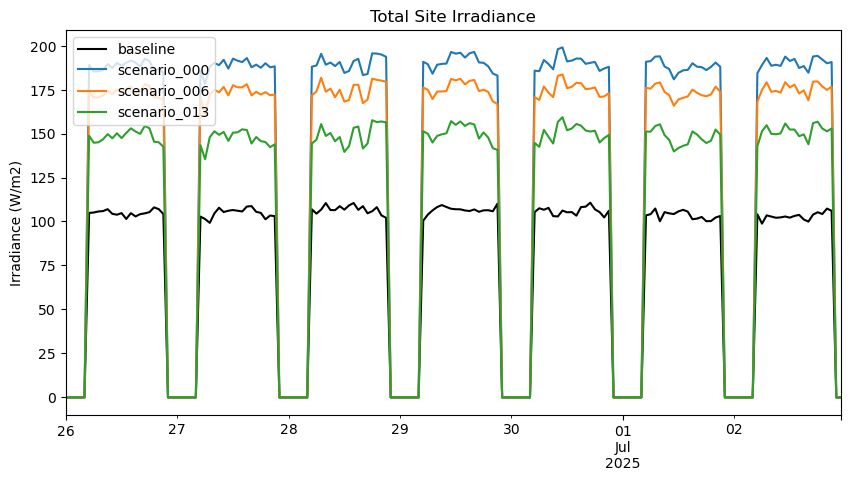

In [49]:
s = 4224


baseline = get_total_site_irradiance("baseline")
baseline.index = pd.date_range(start='2025-01-01', periods=len(baseline), freq='h')

fig, ax = plt.subplots(figsize=(10,5))

baseline.iloc[s:s+168].plot(ax=ax, label='baseline', color='k')

for scen in ["scenario_000", "scenario_006", "scenario_013"]:
    scenario = get_total_site_irradiance(scen)
    scenario.index = pd.date_range(start='2025-01-01', periods=len(scenario), freq='h')
    scenario.iloc[s:s+168].plot(ax=ax, label=scen)

ax.legend(loc='upper left')
ax.set_ylabel('Irradiance (W/m2)')
ax.set_title('Total Site Irradiance')



<Axes: >

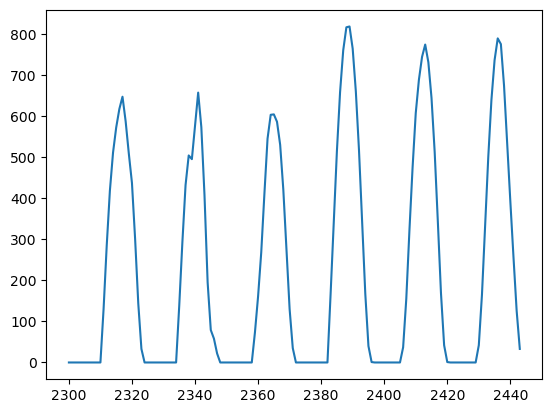

In [7]:
import weather_loader
epw_file = "weather.epw"
weather_data = weather_loader.load_epw(epw_file)
weather_data[s:s+144]['K_down'].plot()

# Leaf Size

In [76]:
import tree_species_database_mapping

In [30]:
f = "/Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/leaf_size_TRY/46437.txt"

# Try different encodings - the file contains special characters like "Díaz" and "Ülo"
# Common encodings for such files are Windows-1252, Latin-1, or UTF-8 with errors handling
encodings_to_try = ['windows-1252', 'latin-1', 'iso-8859-1', 'cp1252', 'utf-8']

df = None
for enc in encodings_to_try:
    try:
        df = pd.read_csv(f, sep='\t', encoding=enc, low_memory=False)
        print(f"✓ Successfully read file with encoding: {enc}")
        print(f"  Shape: {df.shape}")
        break
    except UnicodeDecodeError:
        continue
    except Exception as e:
        print(f"✗ Error with {enc}: {type(e).__name__}")
        continue

if df is None:
    # If all encodings fail, try with error handling
    print("Trying with errors='replace' (will replace problematic characters)...")
    df = pd.read_csv(f, sep='\t', encoding='utf-8', errors='replace', low_memory=False)
    print(f"  Shape: {df.shape}")

species = df['AccSpeciesName'].unique()

df.columns

✓ Successfully read file with encoding: windows-1252
  Shape: (199214, 29)


Index(['LastName', 'FirstName', 'DatasetID', 'Dataset', 'SpeciesName',
       'AccSpeciesID', 'AccSpeciesName', 'ObservationID', 'ObsDataID',
       'TraitID', 'TraitName', 'DataID', 'DataName', 'OriglName',
       'OrigValueStr', 'OrigUnitStr', 'ValueKindName', 'OrigUncertaintyStr',
       'UncertaintyName', 'Replicates', 'StdValue', 'UnitName',
       'RelUncertaintyPercent', 'OrigObsDataID', 'ErrorRisk', 'Reference',
       'Comment', 'StdValueStr', 'Unnamed: 28'],
      dtype='object')

In [ ]:
df['DataName'].unique()

array(['Identifier within contributed dataset (ID)', 'Location Site ID',
       'Location / Site Name', 'Reference / source', 'Family',
       'Plant growth form', 'Woodiness', 'Leaf phenology type',
       'Leaf compoundness', 'Latitude', 'Longitude', 'Altitude',
       'Leaf area: in case of compound leaves leaflet; undefined if petiole in- or excluded',
       'Number of leaflets per leaf sunleaves',
       'Leaf area: in case of compound leaves leaf; undefined if petiole in- or excluded'],
      dtype=object)

In [ ]:
sub_df = df[['DataName','AccSpeciesName','OrigValueStr', 'OrigUnitStr', 'ValueKindName','ObservationID']].copy()
sub_df = sub_df.drop_duplicates(subset=['AccSpeciesName', 'ObservationID'], keep='first')
sub_df = sub_df.groupby('AccSpeciesName').first().reset_index()
sub_df.drop(columns=['ObservationID'], inplace=True)
# Leaf area: in case of compound leaves leaflet; undefined if petiole in- or excluded


,AccSpeciesName,DataName,OrigValueStr,OrigUnitStr,ValueKindName
1256,Ceanothus cuneatus var. cuneatus,Leaf area: in case of compound leaves leaflet;...,2.04945454545454,cm2,Site specific mean
325,Alphonsea monogyna,Identifier within contributed dataset (ID),4343,None,None
1703,Coprosma rubra,Leaf area: in case of compound leaves leaflet;...,1.6595614,cm2,Site specific mean
3974,Ligustrum sinense,Identifier within contributed dataset (ID),17307,None,None
7380,Weinmannia balbisiana,Leaf area: in case of compound leaves leaflet;...,10.7,cm2,Site specific mean
5736,Pultenaea foliolosa,Leaf area: in case of compound leaves leaflet;...,1.33333333333333E-02,cm2,Site specific mean


In [91]:
data_needed = ['Leaf area: in case of compound leaves leaflet; undefined if petiole in- or excluded',
               'Leaf phenology type']

# Filter to only the data we need
filtered_df = df[df['DataName'].isin(data_needed)].copy()

# Pivot to create columns for each DataName
pivoted_df = filtered_df.pivot_table(
    index='AccSpeciesName',
    columns='DataName',
    values='OrigValueStr',
    aggfunc='first'
).reset_index()

# Rename columns to be more concise
pivoted_df.columns.name = None  # Remove the 'DataName' label from columns
pivoted_df = pivoted_df.rename(columns={
    'Leaf area: in case of compound leaves leaflet; undefined if petiole in- or excluded': 'LeafArea_cm2',
    'Leaf phenology type': 'LeafPhenology'
})

# Merge back with original sub_df to keep other columns if needed
# Or replace sub_df entirely with the pivoted version
sub_df = pivoted_df

sub_df['LeafArea_cm2'] = sub_df['LeafArea_cm2'].astype(float).round(2)
# sub_df = sub_df[(sub_df['LeafPhenology']=='D') | (sub_df['LeafPhenology']=='E')]

# Calculate average leaf area per species (averaging across phenologies if multiple exist)
sub_df = sub_df.groupby('AccSpeciesName').agg({
    'LeafArea_cm2': 'mean'
}).reset_index()

sub_df['LeafArea_cm2'] = sub_df['LeafArea_cm2'].round(2)
sub_df.reset_index(drop=True).to_csv('../leaf_size_TRY/leaf_size_TRY.csv',index=False)


In [92]:
sub_df

,AccSpeciesName,LeafArea_cm2
0,ALISMA PLANTAGO-AQUATICA,60.75
1,ARCTOSTAPHYLOS UVA-URSI,4.00
2,Abarema adenophora,30.38
3,Abarema alexandrae,6.75
4,Abarema barbouriana,0.30
...,...,...
7418,Zygophyllum rosowii,0.66
7419,Zygophyllum sonderi,2.21
7420,Zygophyllum sp,0.06
7421,liana sp,85.00


In [94]:
in_model = pd.read_csv('grid_records/baseline_trees.csv')['species'].unique()
in_model_species = pd.Series(in_model).map(tree_species_database_mapping.naming_dict)

missing = []
for my_species in in_model_species:
    if my_species in [c.replace(' ','_') for c in sub_df['AccSpeciesName'].unique()]:
        print("Yes ", my_species)
    else:
        print("No ", my_species)
        missing.append(my_species)


Yes  Fraxinus_mandshurica
No  Picea_pungens
Yes  Fraxinus_pennsylvanica
Yes  Ulmus_americana
No  Acer_ginnala
Yes  Acer_saccharinum
Yes  Picea_glauca
Yes  Elaeagnus_angustifolia
No  Ulmus_pumila
Yes  Syringa_reticulata
Yes  Pinus_sylvestris
No  Fraxinus_nigra
No  Pinus_ponderosa
No  Malus_hybrida
Yes  Tilia_americana
Yes  Larix_laricina
No  Ulmus_davidiana_var_japonica


In [103]:
sub_df[sub_df['AccSpeciesName'] == 'Prunus maackii']

,AccSpeciesName,LeafArea_cm2


In [110]:
# made manually
alternatives_for_missing = {'Picea pungens':'Picea sitchensis',
                            'Acer ginnala':'Acer tataricum',
                            'Ulmus pumila':'Ulmus parvifolia',
                            'Fraxinus nigra':'Fraxinus pennsylvanica',
                            'Pinus ponderosa':'Pinus strobus',
                            'Malus hybrida':'Malus domestica',
                            'Ulmus davidiana var japonica':'Ulmus americana'}

tree_data_fp = "archive/tree_species_database_old.csv"
tree_data = pd.read_csv(tree_data_fp)

def map_leaf_area(species, source_df, alternatives):
    species = species.replace('_',' ')
    if species in source_df['AccSpeciesName'].unique():
        return source_df[source_df['AccSpeciesName'] == species]['LeafArea_cm2'].iloc[0]
    elif species in alternatives:
        return source_df[source_df['AccSpeciesName'] == alternatives[species]]['LeafArea_cm2'].iloc[0]
    else:
        return None

tree_data['LeafArea_cm2'] = tree_data['species'].apply(lambda x: map_leaf_area(x, sub_df, alternatives_for_missing))
tree_data['leaf_char_size'] = np.sqrt(tree_data['LeafArea_cm2']) / 100
tree_data.to_csv('tree_species_database.csv', index=False)


# Leaf Temp

In [89]:
results_files = [f for f in glob.glob("analysis_outputs/biophysical*") if "baseline" not in f]

leaf_temps = []

for f in results_files:
    scenario = int(f.split("_")[-1].split(".")[0])
    df = pd.read_csv(f)
    
    leaf_temps.append(df.groupby('hour')['T_leaf'].mean().rename(f"scenario_{str(scenario).zfill(2)}"))

df = pd.concat(leaf_temps, axis=1)

df.set_index(pd.date_range(start='2025-01-01', periods=8760, freq='h')[4224:4392], inplace=True)

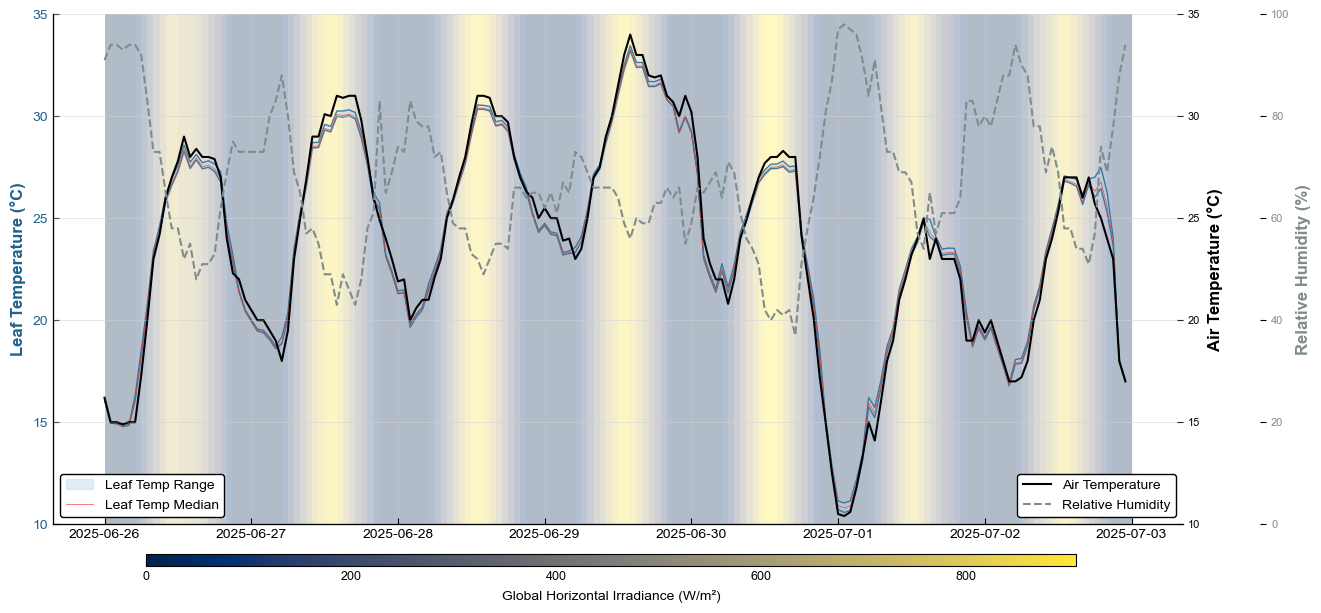

In [302]:
import weather_loader
import matplotlib.colors as mcolors

# Load weather data for the same time period
epw_file = "weather.epw"
weather_data = weather_loader.load_epw(epw_file)
# Match the time period (4224:4392 hours from start of year)
weather_subset = weather_data.iloc[4224:4392].reset_index(drop=True)

# Set up the plot style
pf.set_project_style(style='paper')

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Add GHI background patches using cividis colormap
# Get GHI values and create color patches
ghi_values = weather_subset['K_down'].values
ghi_norm = mcolors.Normalize(vmin=0, vmax=ghi_values.max())
cmap = plt.cm.cividis

# Create background patches for each hour based on GHI (leave no white space)
for i in range(len(df.index) - 1):
    # Get the color for this hour's GHI
    color = cmap(ghi_norm(ghi_values[i]))
    
    # Create a vertical patch from bottom to top of the plot
    ax1.axvspan(df.index[i], df.index[i+1], 
                facecolor=color, alpha=0.3, zorder=0, linewidth=0)

# Handle the last time point to avoid white space at the end
if len(df.index) > 0:
    color = cmap(ghi_norm(ghi_values[-1]))
    # Extend slightly beyond the last point for visual completeness
    time_delta = df.index[1] - df.index[0] if len(df.index) > 1 else pd.Timedelta(hours=1)
    ax1.axvspan(df.index[-1], df.index[-1] + time_delta,
                facecolor=color, alpha=0.3, zorder=0, linewidth=0)

# Calculate statistics across all scenarios for leaf temperature
leaf_median = df.median(axis=1)
leaf_min = df.min(axis=1)
leaf_max = df.max(axis=1)

# Plot leaf temperature uncertainty band
# Dark blue outer lines with light blue fill and light red median
ax1.fill_between(
    df.index, 
    leaf_min, 
    leaf_max,
    color='#AED6F1',  # Light blue fill
    alpha=0.4,
    label='Leaf Temp Range',
    zorder=2
)
ax1.plot(df.index, leaf_min, color='#1F618D', linewidth=1, alpha=0.8, zorder=3)  # Dark blue min
ax1.plot(df.index, leaf_max, color='#1F618D', linewidth=1, alpha=0.8, zorder=3)  # Dark blue max
ax1.plot(df.index, leaf_median, color='#E74C3C', linewidth=0.5, label='Leaf Temp Median', zorder=4)  # Light red median

# Format primary y-axis (leaf temperature)
pf.format_plot(
    ax1,
    # xlabel='Date/Time',
    ylabel='Leaf Temperature (°C)',
    title=None,
    ylim=(10, 35),
    legend=False  # We'll create a custom legend
)
ax1.set_ylabel('Leaf Temperature (°C)', color='#1F618D', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1F618D')

# Create secondary y-axis for air temperature
ax2 = ax1.twinx()
ax2.plot(df.index, weather_subset['Ta'].values, color='black', linewidth=1.5, 
         label='Air Temperature', linestyle='-')
ax2.set_ylabel('Air Temperature (°C)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(10, 35)  # Match leaf temperature scale

# Create third y-axis for relative humidity (extended)
ax3 = ax1.twinx()
# Offset the third axis to the right
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df.index, weather_subset['RH'].values, color='#7F8C8D', linewidth=1.5,
         label='Relative Humidity', linestyle='--')
ax3.set_ylabel('Relative Humidity (%)', color='#7F8C8D', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='#7F8C8D')
ax3.set_ylim(0, 100)

# Create combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1, labels1, 
          loc='lower left', frameon=True, facecolor='white', edgecolor='k', 
          framealpha=1, fontsize=10)

ax2.legend(lines2 + lines3, labels2 + labels3, 
          loc='lower right', frameon=True, facecolor='white', edgecolor='k', 
          framealpha=1, fontsize=10)

# Add horizontal colorbar below the x-axis for GHI
# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=ghi_norm)
sm.set_array([])  # Required for ScalarMappable

# Add colorbar below the plot
# Position: [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.125, 0.05, 0.775, 0.02])  # Thin horizontal bar below x-axis
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Global Horizontal Irradiance (W/m²)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Apply tight layout (but leave space for colorbar)
plt.subplots_adjust(bottom=0.12)  # Make room for the colorbar
plt.savefig("plots/fig04_leaf_temp_uncertainty.png", dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('analysis_outputs/plots/fig04_leaf_temp_uncertainty.png'), dpi=300, bbox_inches='tight')


# Percent Change

In [108]:

pct_df = pd.read_csv('analysis_outputs/pct_change_summary.csv')



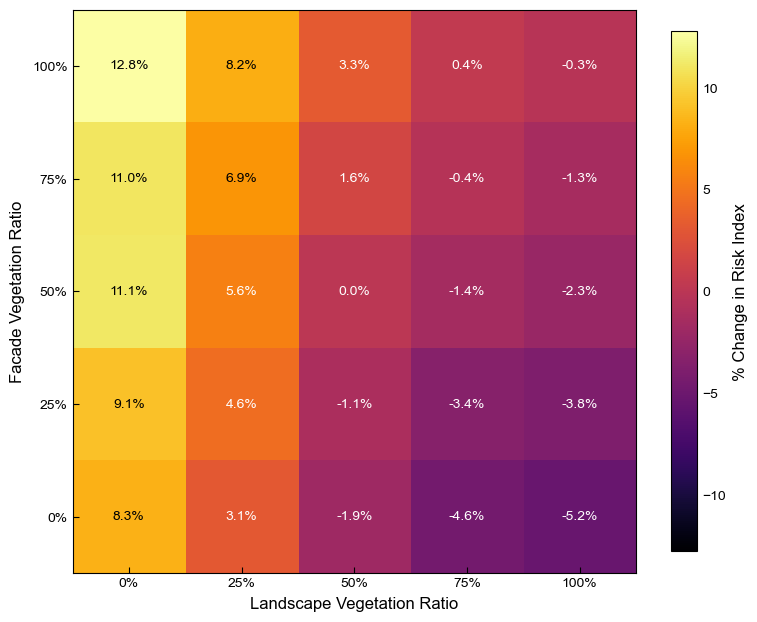

In [301]:
pf.set_project_style()

fig, ax = plt.subplots(figsize=(8, 7))
    
# Create pivot table for heatmap
pivot_data = pct_df.pivot(
    index='facade_ratio',
    columns='landscape_ratio',
    values='degree_hours_pct_change'
)

# Determine color scale centered on zero
vmax = max(abs(pivot_data.min().min()), abs(pivot_data.max().max()))
vmin = -vmax

im = ax.imshow(pivot_data.values, cmap='inferno', vmin=vmin, vmax=vmax, aspect='equal', origin='lower')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='% Change in Risk Index', shrink=0.8)

# Add annotations
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        color = 'k' if abs(val) > vmax*0.5 else 'white'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontsize=10)

ax.set_xticks(range(len(pivot_data.columns)))
ax.set_xticklabels([f'{x:.0%}' for x in pivot_data.columns])
ax.set_yticks(range(len(pivot_data.index)))
ax.set_yticklabels([f'{y:.0%}' for y in pivot_data.index])
ax.set_xlabel('Landscape Vegetation Ratio')
ax.set_ylabel('Facade Vegetation Ratio')
# ax.set_title('Percent Change in Tree Risk Index\n(Relative to Middle Scenario 50%/50%)')

ax.grid(False)

ax.axes.spines['top'].set_visible(True)
ax.axes.spines['right'].set_visible(True)

plt.tight_layout()
plt.savefig("plots/fig05_pct_change_heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('analysis_outputs/plots/fig05_pct_change_heatmap.png'), dpi=300, bbox_inches='tight')

# Sensitivity Analysis

In [299]:
sensitivity_df = run_analysis.run_sensitivity_analysis(pct_df)
sensitivity_df.head()


SECTION 4: SENSITIVITY ANALYSIS

   Calculating area-weighted material properties...

   Risk vs Albedo:
      Slope: 61.04 %/unit albedo
      R²: 0.871
      p-value: 0.0000

   Risk vs Emissivity:
      Slope: -194.21 %/unit emissivity
      R²: 0.638
      p-value: 0.0000

   Tsurf vs Albedo:
      Slope: -89.39 %/unit albedo
      R²: 0.898
      p-value: 0.0000

   Saved: /Users/jmccarty/Nextcloud/Projects/35_UHI_Trees_Manitoba/00_data_code/jodla_project/analysis_outputs/sensitivity_analysis.csv


,scenario_id,landscape_ratio,facade_ratio,mean_albedo,mean_emissivity,total_area,degree_hours_pct_change,mean_Tsurf_C_pct_change,mean_MRT_C_pct_change
0,scenario_000,0.00,0.0,0.358600,0.902590,74466.84,8.330933,-10.021975,-9.605575
1,scenario_001,0.25,0.0,0.306619,0.916105,74466.84,3.095496,-7.388818,-7.094884
2,scenario_002,0.50,0.0,0.279189,0.923237,74466.84,-1.881263,3.950110,3.780760
3,scenario_003,0.75,0.0,0.193554,0.945502,74466.84,-4.560225,3.163860,3.131214
4,scenario_004,1.00,0.0,0.143100,0.958620,74466.84,-5.208572,9.662670,9.297007


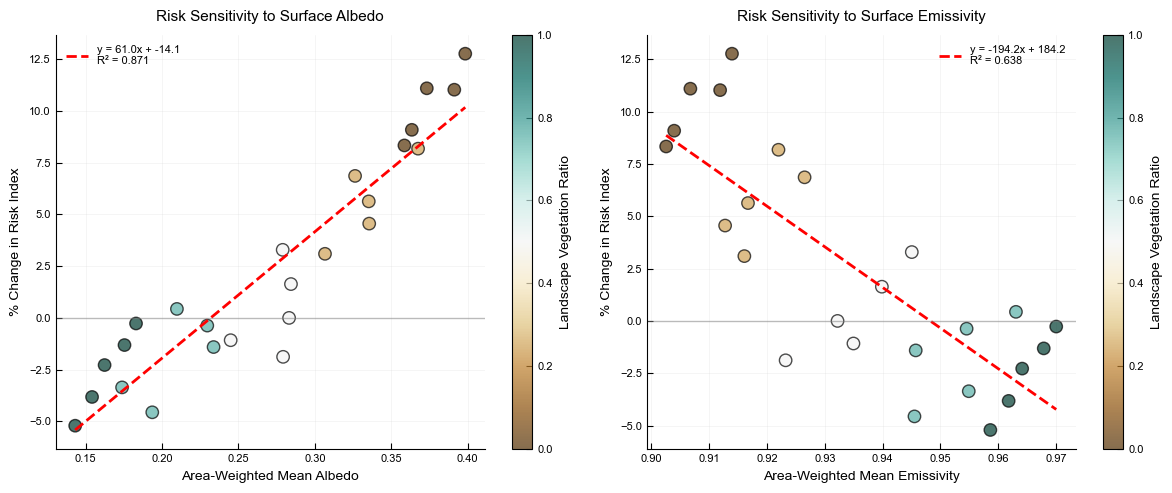

In [300]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
# Risk vs Albedo
ax = axes[0]
cmap = 'BrBG'
valid = sensitivity_df.dropna(subset=['mean_albedo', 'degree_hours_pct_change'])
cax = ax.scatter(valid['mean_albedo'], valid['degree_hours_pct_change'], 
            c=valid['landscape_ratio'], cmap=cmap, s=80, edgecolor='black', alpha=0.7)
fig.colorbar(cax, label='Landscape Vegetation Ratio')
if 'regression' in sensitivity_df.attrs:
    reg = sensitivity_df.attrs['regression']['risk_albedo']
    x_line = np.linspace(valid['mean_albedo'].min(), valid['mean_albedo'].max(), 100)
    y_line = reg['slope'] * x_line + reg['intercept']
    ax.plot(x_line, y_line, 'r--', linewidth=2, 
            label=f"y = {reg['slope']:.1f}x + {reg['intercept']:.1f}\nR² = {reg['r2']:.3f}")
    ax.legend(loc='best')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Area-Weighted Mean Albedo')
ax.set_ylabel('% Change in Risk Index')
ax.set_title('Risk Sensitivity to Surface Albedo')

# Risk vs Emissivity
ax = axes[1]
cax = ax.scatter(valid['mean_emissivity'], valid['degree_hours_pct_change'], 
            c=valid['landscape_ratio'], cmap=cmap, s=80, edgecolor='black', alpha=0.7)

fig.colorbar(cax, label='Landscape Vegetation Ratio')

if 'regression' in sensitivity_df.attrs:
    reg = sensitivity_df.attrs['regression']['risk_emissivity']
    x_line = np.linspace(valid['mean_emissivity'].min(), valid['mean_emissivity'].max(), 100)
    y_line = reg['slope'] * x_line + reg['intercept']
    ax.plot(x_line, y_line, 'r--', linewidth=2,
            label=f"y = {reg['slope']:.1f}x + {reg['intercept']:.1f}\nR² = {reg['r2']:.3f}")
    ax.legend(loc='best')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Area-Weighted Mean Emissivity')
ax.set_ylabel('% Change in Risk Index')
ax.set_title('Risk Sensitivity to Surface Emissivity')

plt.tight_layout()
plt.savefig(os.path.join('plots/fig06_sensitivity_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('analysis_outputs/plots/fig06_sensitivity_curves.png'), dpi=300, bbox_inches='tight')

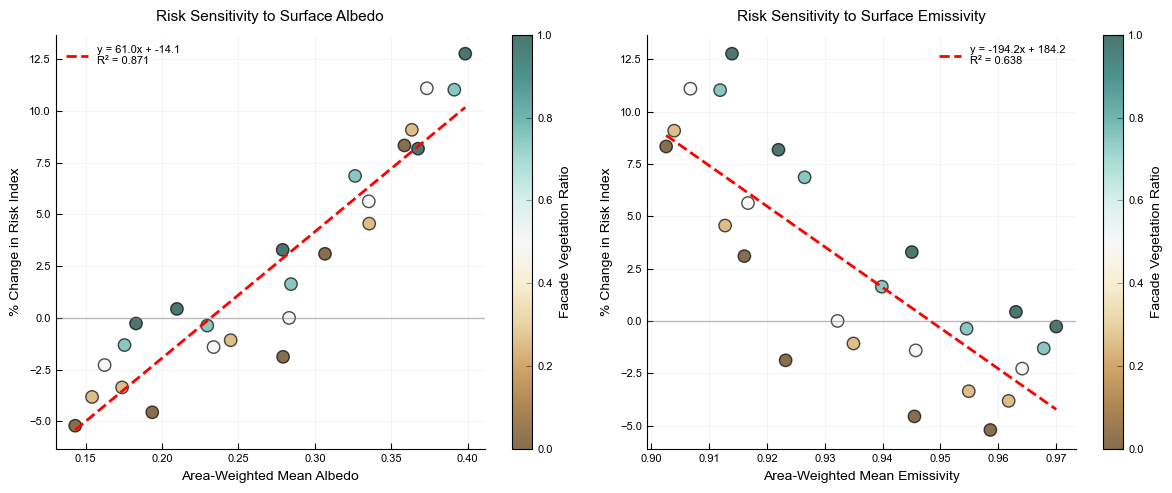

In [312]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
# Risk vs Albedo
ax = axes[0]
cmap = 'BrBG'
valid = sensitivity_df.dropna(subset=['mean_albedo', 'degree_hours_pct_change'])
cax = ax.scatter(valid['mean_albedo'], valid['degree_hours_pct_change'], 
            c=valid['facade_ratio'], cmap=cmap, s=80, edgecolor='black', alpha=0.7)
fig.colorbar(cax, label='Facade Vegetation Ratio')
if 'regression' in sensitivity_df.attrs:
    reg = sensitivity_df.attrs['regression']['risk_albedo']
    x_line = np.linspace(valid['mean_albedo'].min(), valid['mean_albedo'].max(), 100)
    y_line = reg['slope'] * x_line + reg['intercept']
    ax.plot(x_line, y_line, 'r--', linewidth=2, 
            label=f"y = {reg['slope']:.1f}x + {reg['intercept']:.1f}\nR² = {reg['r2']:.3f}")
    ax.legend(loc='best')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Area-Weighted Mean Albedo')
ax.set_ylabel('% Change in Risk Index')
ax.set_title('Risk Sensitivity to Surface Albedo')

# Risk vs Emissivity
ax = axes[1]
cax = ax.scatter(valid['mean_emissivity'], valid['degree_hours_pct_change'], 
            c=valid['facade_ratio'], cmap=cmap, s=80, edgecolor='black', alpha=0.7)

fig.colorbar(cax, label='Facade Vegetation Ratio')

if 'regression' in sensitivity_df.attrs:
    reg = sensitivity_df.attrs['regression']['risk_emissivity']
    x_line = np.linspace(valid['mean_emissivity'].min(), valid['mean_emissivity'].max(), 100)
    y_line = reg['slope'] * x_line + reg['intercept']
    ax.plot(x_line, y_line, 'r--', linewidth=2,
            label=f"y = {reg['slope']:.1f}x + {reg['intercept']:.1f}\nR² = {reg['r2']:.3f}")
    ax.legend(loc='best')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Area-Weighted Mean Emissivity')
ax.set_ylabel('% Change in Risk Index')
ax.set_title('Risk Sensitivity to Surface Emissivity')

plt.tight_layout()
plt.savefig('plots/fig06b_sensitivity_curves_facade.png', dpi=300, bbox_inches='tight')


# Material Properties

In [313]:
import plots

   Saved: plots/material_properties_comparison.png


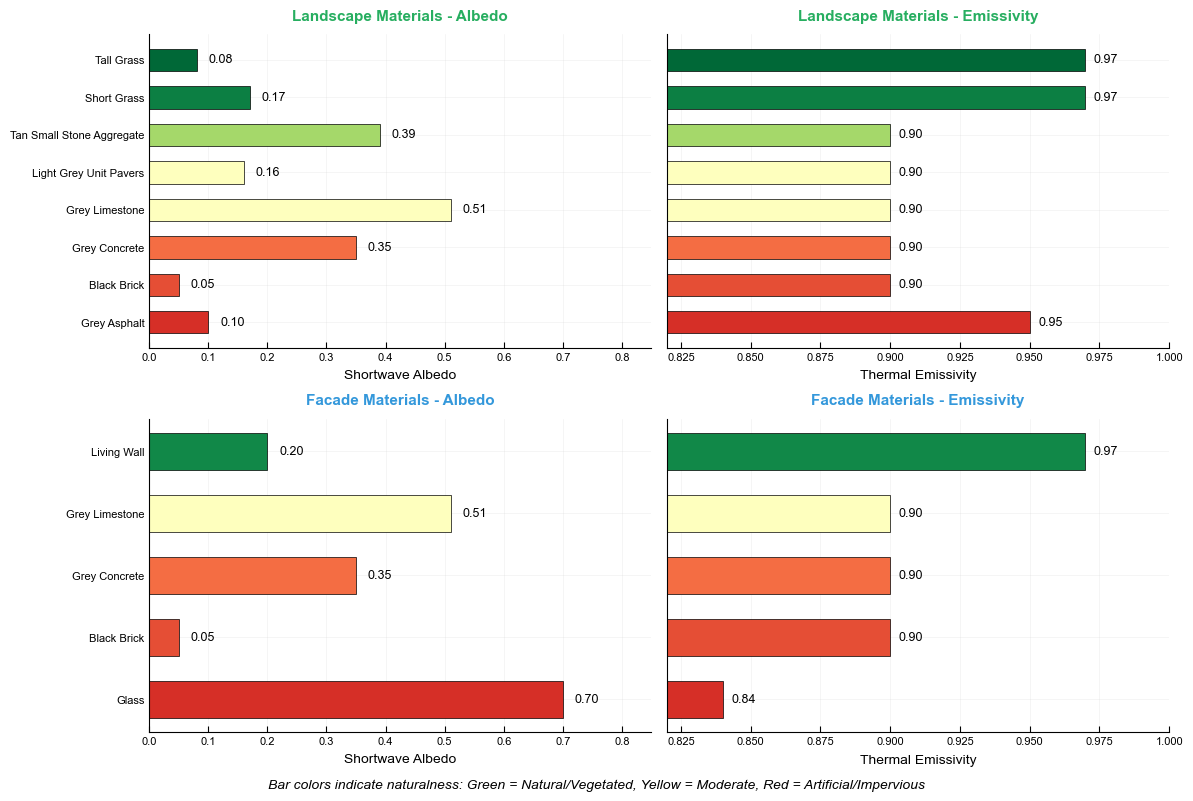

In [314]:
fig = plots.plot_material_properties_comparison(
    material_db_path='root_material_database.csv',
    output_path='plots/material_properties_comparison.png'
)